# Titanic Survival Analysis 🛳️

## Project Overview
This project analyzes Titanic passenger data to understand survival factors and predict outcomes using logistic regression.

---

## 1️⃣ Load Data
We start by importing necessary libraries and loading the Titanic dataset.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("titanic.csv")
df.head()


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


## 2️⃣ Data Cleaning
We handle missing values and drop unnecessary columns.

In [2]:

df['age'] = df['age'].fillna(df['age'].median())
df['embarked'] = df['embarked'].fillna(df['embarked'].mode()[0])
df['embark_town'] = df['embark_town'].fillna(df['embark_town'].mode()[0])
df = df.drop(columns=['deck'])
df.isnull().sum()


survived       0
pclass         0
sex            0
age            0
sibsp          0
parch          0
fare           0
embarked       0
class          0
who            0
adult_male     0
embark_town    0
alive          0
alone          0
dtype: int64

## 3️⃣ Exploratory Data Analysis (EDA)

### Overall Survival Rate

In [3]:

round(df['survived'].mean()*100, 2)


np.float64(38.38)

### Survival Rate by Gender

In [4]:
round(df.groupby('sex')['survived'].mean()*100, 2)


sex
female    74.20
male      18.89
Name: survived, dtype: float64

### Survival Rate by Passenger Class

In [5]:
round(df.groupby('pclass')['survived'].mean()*100, 2)


pclass
1    62.96
2    47.28
3    24.24
Name: survived, dtype: float64

### Visualization
We visualize survival distributions and trends using seaborn.

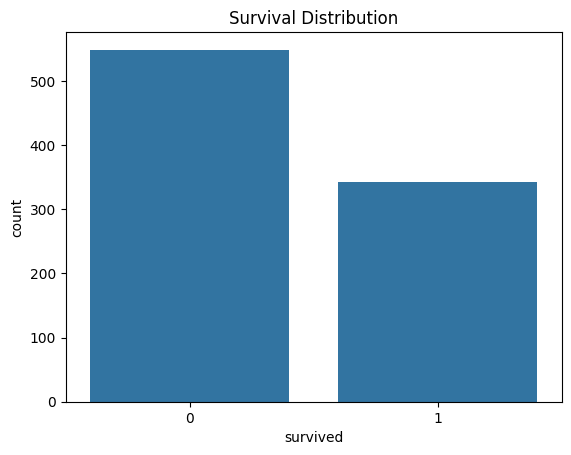

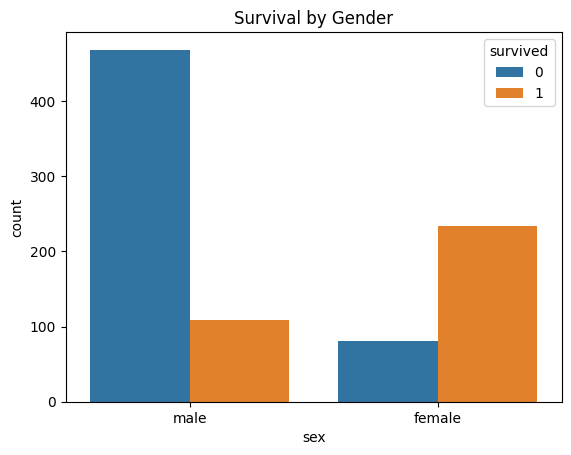

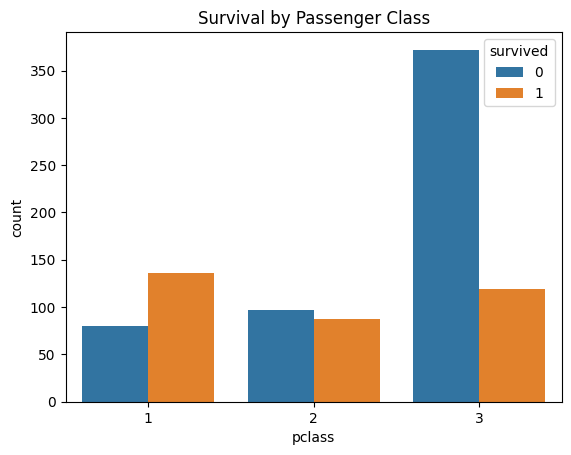

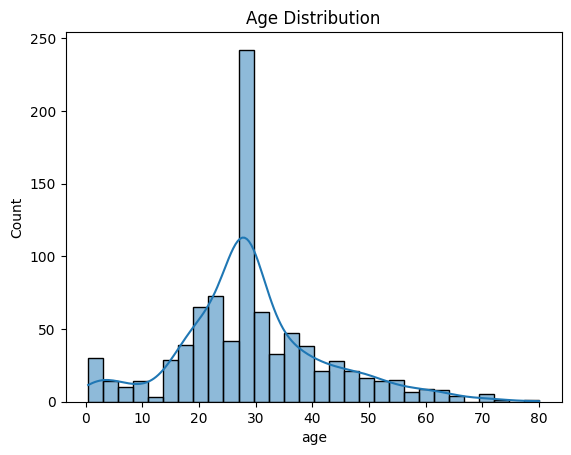

In [6]:
 
 # Survival distribution
sns.countplot(x='survived', data=df)
plt.title("Survival Distribution")
plt.show()

# Survival by gender
sns.countplot(x='sex', hue='survived', data=df)
plt.title("Survival by Gender")
plt.show()

# Survival by passenger class
sns.countplot(x='pclass', hue='survived', data=df)
plt.title("Survival by Passenger Class")
plt.show()

# Age distribution
sns.histplot(df['age'], bins=30, kde=True)
plt.title("Age Distribution")
plt.show()


## 4️⃣ Feature Engineering
We drop unnecessary columns and convert categorical variables into numeric.

In [7]:

# Drop unnecessary columns
df = df.drop(columns=['alive', 'who', 'class', 'embark_town'])

# Convert categorical variables to numeric
df = pd.get_dummies(df, columns=['sex', 'embarked'], drop_first=True)


## 5️⃣ Model Building
We build a logistic regression model to predict survival.

In [8]:

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# Features and target
X = df.drop('survived', axis=1)
y = df['survived']

# Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Model
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

# Prediction
y_pred = model.predict(X_test)

# Accuracy
print("Accuracy:", accuracy_score(y_test, y_pred))


Accuracy: 0.8156424581005587


## 6️⃣ Model Evaluation
We evaluate the model using confusion matrix and classification report.

In [9]:

from sklearn.metrics import classification_report, confusion_matrix

# Confusion Matrix
print(confusion_matrix(y_test, y_pred))

# Classification Report
print(classification_report(y_test, y_pred))

[[91 14]
 [19 55]]
              precision    recall  f1-score   support

           0       0.83      0.87      0.85       105
           1       0.80      0.74      0.77        74

    accuracy                           0.82       179
   macro avg       0.81      0.80      0.81       179
weighted avg       0.81      0.82      0.81       179



## Key Insights

- Overall survival rate: ~38%
- Female passengers survived more (~74%) than males (~19%)
- First-class passengers survived more than others
- Model accuracy: 81.5%